# Notebook 01: Data Loading & Dataset Summary  
### Final Year Project – Sign Language Gesture Recognition (Single + Two Hand)

**Objectives:**
- Load raw dataset
- Verify directory structure
- Generate basic dataset summary
- Ensure data pipeline integrity


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ROOT = Path("../dataset")
assert DATASET_ROOT.exists()


In [2]:
TWO_HAND = ["afraid","agree","assistance","doctor","form","pray",
            "skin","small","stand","today","which","work"]

SINGLE_HAND = ["bad","become","college","pain",
               "secondary","specific","warn","you"]

ALL = TWO_HAND + SINGLE_HAND


In [3]:
summary = []

for g in ALL:
    gpath = DATASET_ROOT / g
    if not gpath.exists(): 
        continue
    users = list(gpath.glob("User_*"))
    images = sum(len(list(u.glob("*.jpg"))) + len(list(u.glob("*.png"))) for u in users)

    summary.append({
        "gesture": g,
        "hand_type": "two-hand" if g in TWO_HAND else "single-hand",
        "users": len(users),
        "images": images
    })

df = pd.DataFrame(summary)
df


,gesture,hand_type,users,images
0,afraid,two-hand,6,900
1,agree,two-hand,6,900
2,assistance,two-hand,6,900
3,doctor,two-hand,5,750
4,pray,two-hand,6,900
5,skin,two-hand,6,900
6,small,two-hand,6,900
7,stand,two-hand,6,900
8,today,two-hand,6,900
9,which,two-hand,6,900


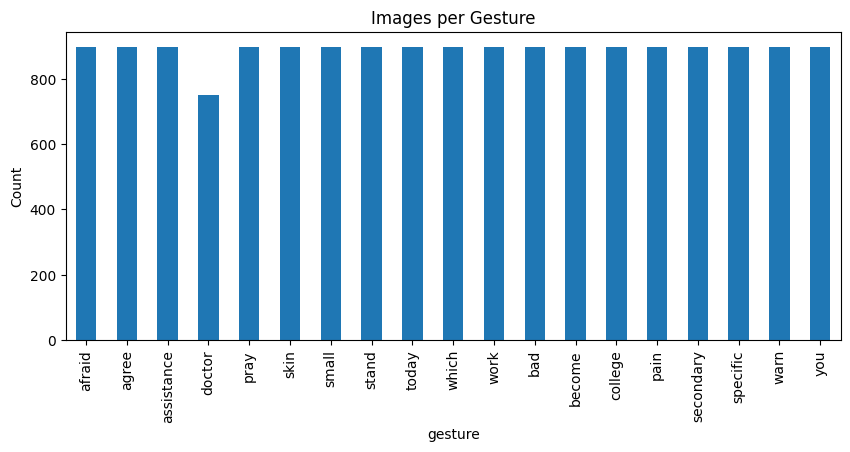

In [4]:
df.plot(x="gesture", y="images", kind="bar", figsize=(10,4), legend=False)
plt.title("Images per Gesture")
plt.ylabel("Count")
plt.show()
